## 0 — Imports & Setup

In [ ]:
import sys, os, numpy as np, torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
sys.path.append('.')   # adjust if your scripts live in a subfolder
from utils.engine import train_model, evaluate

from config import DEVICE, CHECKPOINT_DIR, EPOCHS
from utils.dataloader import get_dataloaders
from models.vgg import VGG16

# get train/val loaders and class names from the existing dataset
train_loader, val_loader, test_loader, class_names = get_dataloaders()
print(f'Dataset loaded successfully with {len(class_names)} classes: {class_names}')

Train images : 1000
Val images   : 36
Test images  : 38
Classes      : ['Angry', 'Other', 'Sad', 'happy']


ValueError: too many values to unpack (expected 3)

## 1 — Train If Needed / Load VGG16 Checkpoint

In [ ]:
vgg = VGG16().to(DEVICE)
checkpoint_path = os.path.join(CHECKPOINT_DIR, 'VGG16.pth')

if os.path.exists(checkpoint_path):
    vgg.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
    vgg.eval()
    print(f'VGG16 loaded from {checkpoint_path}')
else:
    print(f'No checkpoint found at {checkpoint_path}. Training VGG16 first...')
    vgg, best_acc = train_model(vgg, 'VGG16', train_loader, val_loader, class_names, epochs=EPOCHS)
    vgg.eval()
    print(f'VGG16 trained and saved to {checkpoint_path} with best val acc {best_acc:.4f}')

No checkpoint found at c:\Users\alyad\Desktop\lab4\checkpoints\VGG16.pth. Training VGG16 first...

  Training : VGG16  |  device: cpu
Epoch [ 1/30]  Train Loss: 13.2082  Train Acc: 0.2462  |  Val Loss: 13.2816  Val Acc: 0.2250
  Model saved with Val Acc: 0.2250


## 2 — Run Inference

In [ ]:
all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in val_loader:
        preds = vgg(images.to(DEVICE)).argmax(1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
print(f'Val Accuracy: {(all_preds == all_labels).mean():.4f}')

Val Accuracy: 0.2700


## 3 — Confusion Matrix

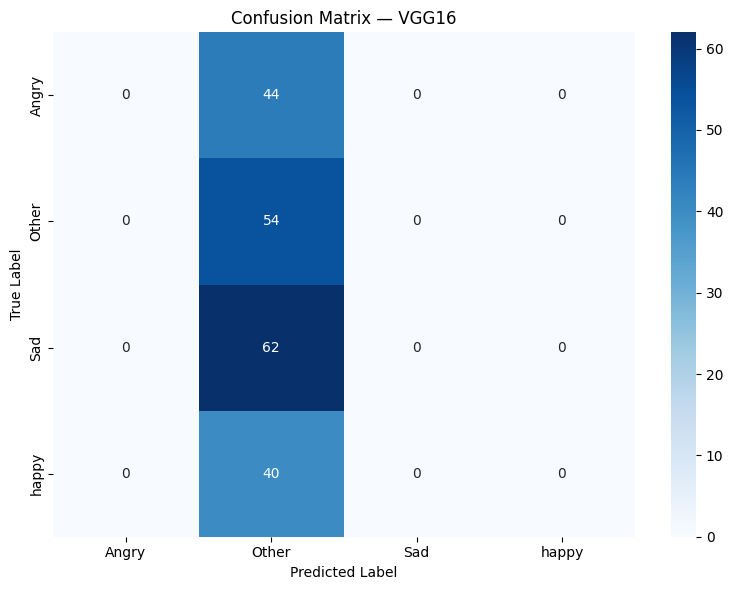

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix — VGG16')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()

## 4 — Per-Class Precision / Recall / F1

c:\Users\alyad\Desktop\lab4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


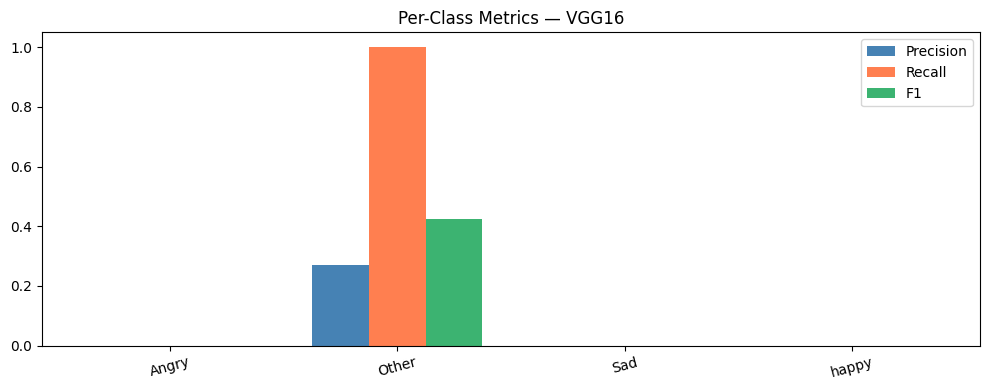

              precision    recall  f1-score   support

       Angry     0.0000    0.0000    0.0000        44
       Other     0.2700    1.0000    0.4252        54
         Sad     0.0000    0.0000    0.0000        62
       happy     0.0000    0.0000    0.0000        40

    accuracy                         0.2700       200
   macro avg     0.0675    0.2500    0.1063       200
weighted avg     0.0729    0.2700    0.1148       200



c:\Users\alyad\Desktop\lab4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyad\Desktop\lab4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\alyad\Desktop\lab4\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
p, r, f, _ = precision_recall_fscore_support(all_labels, all_preds, average=None)

x = np.arange(len(class_names)); w = 0.25
plt.figure(figsize=(10, 4))
plt.bar(x - w, p, w, label='Precision', color='steelblue')
plt.bar(x,     r, w, label='Recall',    color='coral')
plt.bar(x + w, f, w, label='F1',        color='mediumseagreen')
plt.xticks(x, class_names, rotation=15)
plt.ylim(0, 1.05)
plt.title('Per-Class Metrics — VGG16')
plt.legend(); plt.tight_layout(); plt.show()

print(classification_report(all_labels, all_preds,
                             target_names=class_names, digits=4))

## 5 — Training Curves

In [ ]:
# Load history saved during training, or paste your lists manually
history_path = os.path.join(CHECKPOINT_DIR, 'VGG16_history.pt')
if not os.path.exists(history_path):
    raise FileNotFoundError(
        f'History file not found at {history_path}. Train with train_model first.'
    )
history = torch.load(history_path, map_location=DEVICE)

epochs = range(1, len(history['train_acc']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, history['train_loss'], label='Train', marker='o', markersize=3)
ax1.plot(epochs, history['val_loss'],   label='Val',   marker='o', markersize=3)
ax1.set_title('VGG16 — Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, history['train_acc'], label='Train', marker='o', markersize=3)
ax2.plot(epochs, history['val_acc'],   label='Val',   marker='o', markersize=3)
ax2.set_title('VGG16 — Accuracy'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

FileNotFoundError: History file not found at c:\Users\alyad\Desktop\lab4\checkpoints\VGG16_history.pt. Train with train_model first.